In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuration
TICKER = "NVDA"
YEARS_OF_DATA = 2
TEST_SIZE = 0.2
MIN_SAMPLES = 50
PROFIT_TARGET = 0.036   
STOP_LOSS = 0.03 
FORWARD_DAYS = 20

[*********************100%***********************]  1 of 1 completed



=== Regression Model Evaluation ===
R2 Score: 0.9068
RMSE: 0.0344

=== Live Signal (Latest Data) ===
Date: 2025-06-10
Current Price: 143.96
Predicted Max Return (Next 20d): 4.03%
Take Profit: 149.14
Stop Loss: 139.64
>> Suggested Action: ✅ Consider Entry (Expected Return >= 3%)


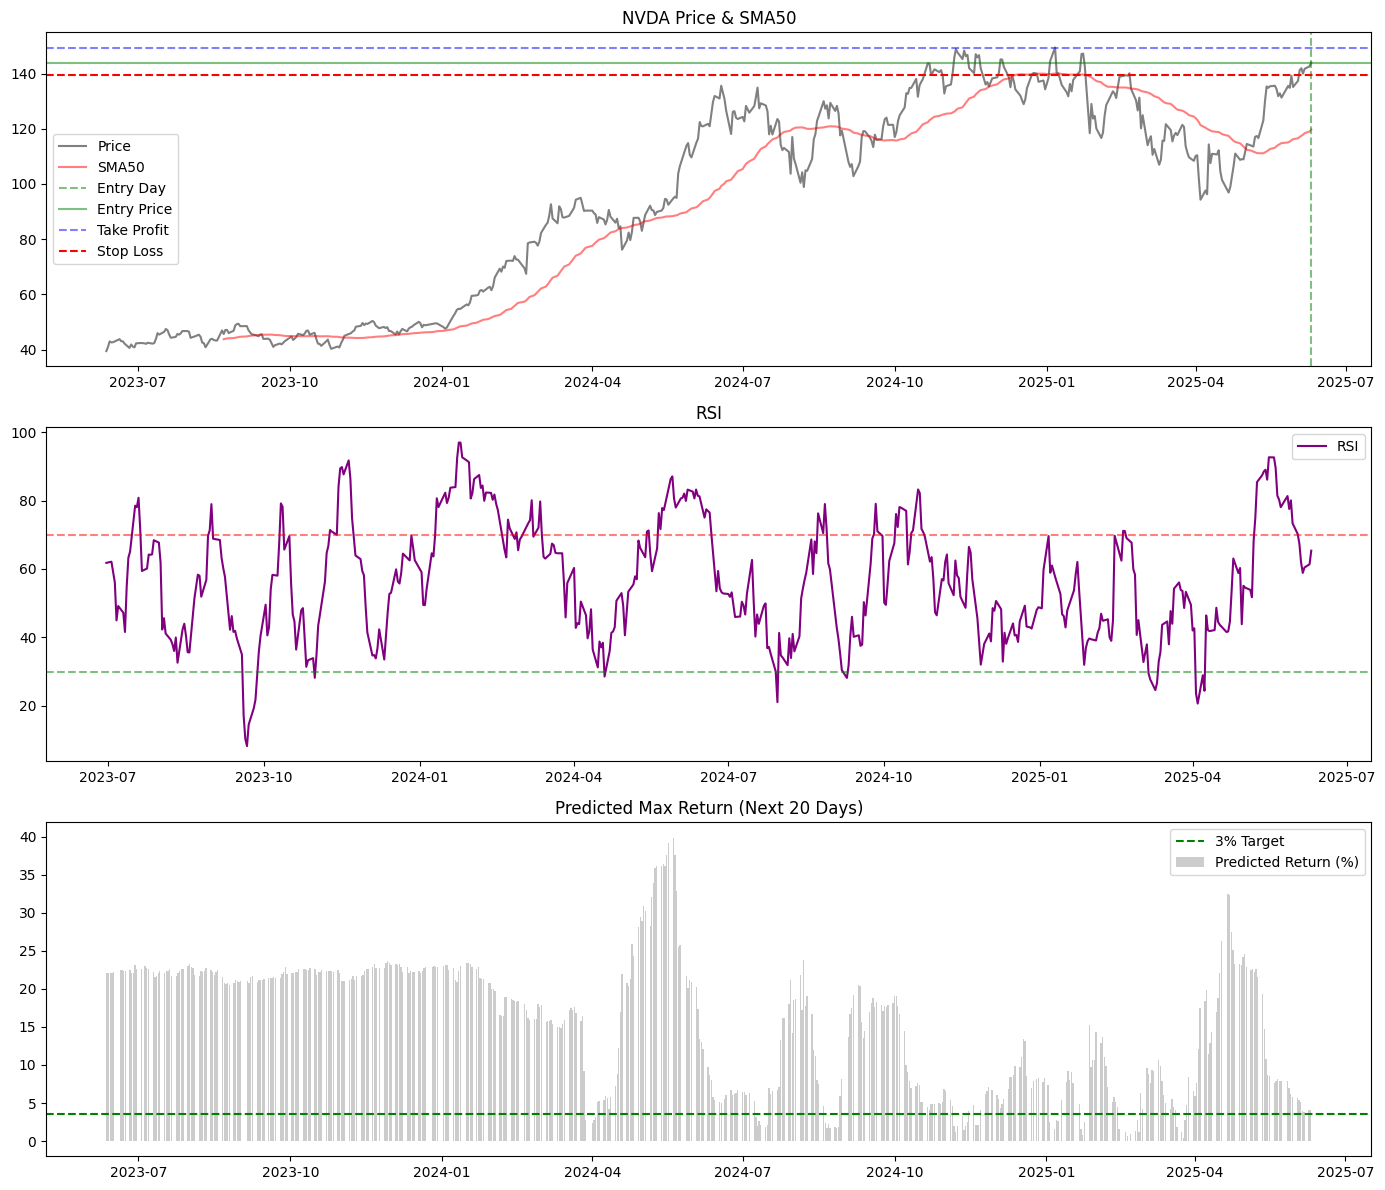

In [3]:
def get_stock_data(ticker, start_date, end_date):
    df = yf.download(ticker, start=start_date, end=end_date + timedelta(days=1), interval='1d', auto_adjust=False)
    df = df.reset_index()
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    return df

def add_technical_indicators(df):
    df['SMA1'] = df['Close'].rolling(window=20).mean()
    df['SMA2'] = df['Close'].rolling(window=50).mean()
    df['SMA3'] = df['Close'].rolling(window=200).mean()

    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(window=14).mean()
    loss = -delta.where(delta < 0, 0).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

    df['Upper_Band'] = df['SMA1'] + (2 * df['Close'].rolling(20).std())
    df['Lower_Band'] = df['SMA1'] - (2 * df['Close'].rolling(20).std())
    df['Volume_MA20'] = df['Volume'].rolling(window=20).mean()
    return df

def compute_expected_return(df, forward_days=20):
    df = df.copy()
    df['Expected_Return'] = np.nan
    close_prices = df['Close'].values

    for i in range(len(close_prices) - forward_days):
        current_price = close_prices[i]
        future_max = np.nanmax(close_prices[i + 1:i + 1 + forward_days])
        expected_return = (future_max - current_price) / current_price
        df.iloc[i, df.columns.get_loc('Expected_Return')] = expected_return

    return df

def build_model_and_predict(data):
    features = ['RSI', 'SMA1', 'SMA2', 'SMA3', 'MACD', 'Signal_Line',
                'Upper_Band', 'Lower_Band', 'Volume_MA20',
                '5_day_return', '10_day_return', 'Volatility']

    df_model = data.dropna(subset=features + ['Expected_Return'])
    X = df_model[features]
    y = df_model['Expected_Return']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=5)
    model.fit(X_train_scaled, y_train)

    print("\n=== Regression Model Evaluation ===")
    y_pred = model.predict(X_test_scaled)
    print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

    # Full prediction for plotting
    data['Predicted_Return'] = model.predict(scaler.transform(data[features].fillna(0)))

    return model, scaler, features, data

if __name__ == "__main__":
    try:
        end_date = datetime.now()
        start_date = end_date - timedelta(days=365 * YEARS_OF_DATA)
        data = get_stock_data(TICKER, start_date, end_date)
        data['Volume'] = pd.to_numeric(data['Volume'], errors='coerce')

        data = add_technical_indicators(data)

        data['5_day_return'] = data['Close'].pct_change(5)
        data['10_day_return'] = data['Close'].pct_change(10)
        data['Volatility'] = data['Close'].rolling(5).std()

        data = compute_expected_return(data)

        model, scaler, features, data = build_model_and_predict(data)

        # Live prediction
        latest = data.iloc[[-1]]
        latest_scaled = scaler.transform(latest[features].fillna(0))
        live_prediction = model.predict(latest_scaled)[0]

        entry_price = latest['Close'].values[0]
        take_profit = entry_price * (1 + PROFIT_TARGET)
        stop_loss = entry_price * (1 - STOP_LOSS)

        print("\n=== Live Signal (Latest Data) ===")
        print(f"Date: {latest.index[-1].date()}")
        print(f"Current Price: {entry_price:.2f}")
        print(f"Predicted Max Return (Next {FORWARD_DAYS}d): {live_prediction*100:.2f}%")
        print(f"Take Profit: {take_profit:.2f}")
        print(f"Stop Loss: {stop_loss:.2f}")

        if live_prediction >= PROFIT_TARGET:
            print(">> Suggested Action: ✅ Consider Entry (Expected Return >= 3%)")
        else:
            print(">> Suggested Action: 🚫 No Entry (Expected Return Too Low)")

        # === Plotting ===
        plt.figure(figsize=(14, 12))

        # Subplot 1: Price + SMA2
        plt.subplot(3, 1, 1)
        plt.plot(data['Close'], label='Price', color='gray')
        plt.plot(data['SMA2'], label='SMA50', color='red', alpha = 0.5)
        plt.title(f'{TICKER} Price & SMA50')

        # Plot entry signal and thresholds
        entry_date = latest.index[-1]
        plt.axvline(entry_date, color='green', linestyle='--', label='Entry Day', alpha = 0.5)
        plt.axhline(entry_price, color='green', linestyle='-', label='Entry Price', alpha = 0.5)
        plt.axhline(take_profit, color='blue', linestyle='--', label='Take Profit', alpha = 0.5)
        plt.axhline(stop_loss, color='red', linestyle='--', label='Stop Loss')

        plt.legend()

        # Subplot 2: RSI
        plt.subplot(3, 1, 2)
        plt.plot(data['RSI'], label='RSI', color='purple')
        plt.axhline(70, linestyle='--', color='red', alpha=0.5)
        plt.axhline(30, linestyle='--', color='green', alpha=0.5)
        plt.title('RSI')
        plt.legend()

        # Subplot 3: Predicted Return
        plt.subplot(3, 1, 3)
        plt.bar(data.index, data['Predicted_Return'] * 100, color='gray', alpha=0.4, label='Predicted Return (%)')
        plt.axhline(PROFIT_TARGET * 100, color='green', linestyle='--', label='3% Target')
        plt.title('Predicted Max Return (Next 20 Days)')
        plt.legend()

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error: {e}")
